In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# Step 0: Import Libraries and Load Raw METR-LA Files
# ============================================================
# This step loads the three main raw files used in the project:
# 1. Traffic speed time-series data
# 2. Sensor adjacency / graph structure
# 3. Pairwise sensor distance information

import os
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Path to METR-LA raw dataset folder
metr_path = "/content/drive/MyDrive/spatiotemporal-traffic-forecasting/datasets/raw/metr_la/"

# Add a check for the directory's existence
if not os.path.exists(metr_path):
    raise FileNotFoundError("The directory '{metr_path}' does not exist. Please ensure the dataset is in the correct Google Drive path.")

print(os.listdir(metr_path))

# Load main traffic speed dataset
df = pd.read_hdf(metr_path + "metr_la.h5")

# Load adjacency / graph dataset
with open(metr_path + "adj_metr_la.pkl", "rb") as f:
    adj_data = pickle.load(f, encoding="latin1")

# Load pairwise sensor distance dataset
dist_df = pd.read_csv(metr_path + "distances_la_2012.csv")


# ============================================================
# Added: Robust Path Detection (Fallback Support)
# ============================================================

def get_valid_metr_path(possible_paths):
    for path in possible_paths:
        if os.path.exists(path):
            print(f"✅ Using dataset path: {path}")
            return path
    raise FileNotFoundError("❌ Dataset not found in any of the expected locations.")

# Add all possible paths teammates might use
possible_paths = [
    "/content/drive/MyDrive/spatiotemporal-traffic-forecasting/datasets/raw/metr_la/",
    "/content/drive/MyDrive/datasets/metr_la/",
    "/content/drive/MyDrive/metr_la/",
    "./datasets/metr_la/"   # local fallback
]

metr_path = get_valid_metr_path(possible_paths)

print("📁 Files in dataset:", os.listdir(metr_path))


['distances_la_2012.csv', 'adj_metr_la.pkl', 'metr_la.h5']
✅ Using dataset path: /content/drive/MyDrive/spatiotemporal-traffic-forecasting/datasets/raw/metr_la/
📁 Files in dataset: ['distances_la_2012.csv', 'adj_metr_la.pkl', 'metr_la.h5']


Traffic dataframe shape: (34272, 207)

First 5 rows:


,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,62.750000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,63.333333,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,65.375000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000



Column sample (sensor IDs):
Index(['773869', '767541', '767542', '717447', '717446', '717445', '773062',
       '767620', '737529', '717816'],
      dtype='object')

Index sample (timestamps):
DatetimeIndex(['2012-03-01 00:00:00', '2012-03-01 00:05:00',
               '2012-03-01 00:10:00', '2012-03-01 00:15:00',
               '2012-03-01 00:20:00'],
              dtype='datetime64[ns]', freq=None)

Missing values: 0
Are timestamps strictly increasing? True
Number of duplicate timestamps: 0
Expected number of timestamps: 34272
Actual number of timestamps: 34272
Missing timestamps (gaps): 0

Zero values: 575302 (8.11% of total data)


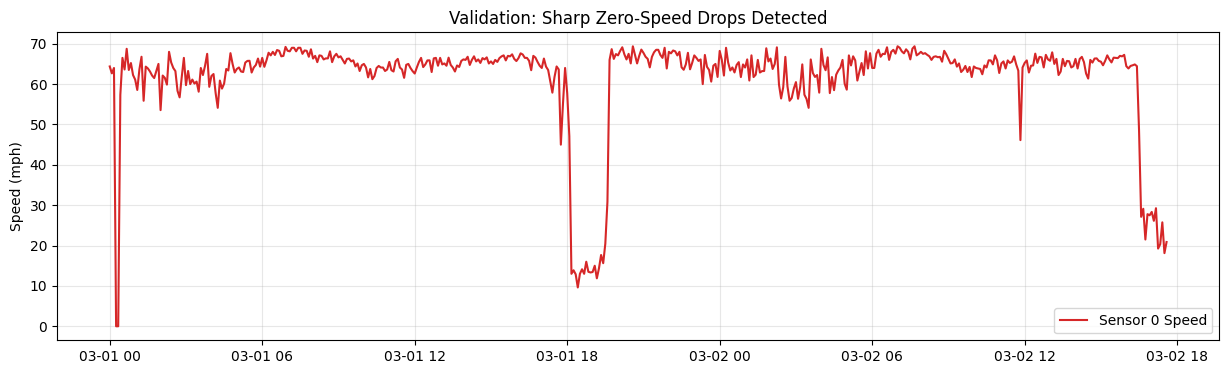

In [ ]:

# Step 1a: Inspect Traffic Time-Series Data

# verifies the structure and integrity of the traffic dataset, including timestamps, sensor columns, and missing values.

# Convert index to proper datetime format (handles byte strings if present)
df.index = pd.to_datetime(
    [x.decode("utf-8") if isinstance(x, bytes) else x for x in df.index]
)


print("Traffic dataframe shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn sample (sensor IDs):")
print(df.columns[:10])

print("\nIndex sample (timestamps):")
print(df.index[:5])


print("\nMissing values:", df.isnull().sum().sum())

# Added: Verify timestamps are strictly increasing (sorted order)
is_sorted = df.index.is_monotonic_increasing
print(f"Are timestamps strictly increasing? {is_sorted}")

if not is_sorted:
    print("Data is not sorted. Sorting now...")
    df = df.sort_index()

# Added: Check for duplicate timestamps
duplicates = df.index.duplicated().sum()
print(f"Number of duplicate timestamps: {duplicates}")

if duplicates > 0:
    print("Removing duplicates...")
    df = df[~df.index.duplicated(keep='first')]

# Added: Confirm time interval consistency (5-minute intervals)
# Difference between consecutive timestamps
expected_freq = '5min'
expected_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq=expected_freq)
missing_timestamps = expected_index.difference(df.index)

print(f"Expected number of timestamps: {len(expected_index)}")
print(f"Actual number of timestamps: {len(df.index)}")
print(f"Missing timestamps (gaps): {len(missing_timestamps)}")

if len(missing_timestamps) > 0:
    print(f"Sample of missing timestamps: {missing_timestamps[:5]}")
    # TODO: In Step 1c, we should re-index and interpolate these gaps.

# Added: Validate whether zero values represent real speeds or missing data
zero_count = (df == 0).sum().sum()
total_count = df.size
print(f"\nZero values: {zero_count} ({ (zero_count/total_count)*100:.2f}% of total data)")

# Visualizing the drops
plt.figure(figsize=(15, 4))
plt.plot(df.iloc[:500, 0], label="Sensor 0 Speed", color='tab:red')
plt.title("Validation: Sharp Zero-Speed Drops Detected")
plt.ylabel("Speed (mph)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Type of adj_data: <class 'list'>
Number of sensors: 207
Adjacency matrix shape: (207, 207)

First 5 sensor IDs:
['773869', '767541', '767542', '717447', '717446']

First 5 mapping entries:
[('717099', 110), ('773869', 0), ('767541', 1), ('767542', 2), ('717447', 3)]


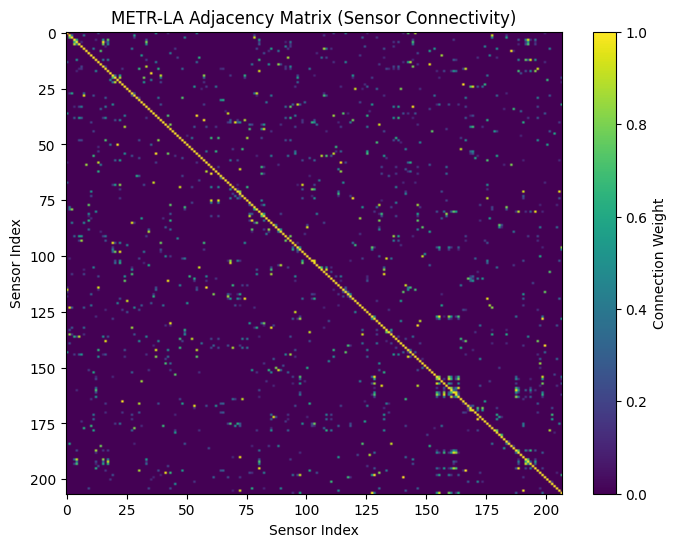


Non-zero entries: 1722
Total entries: 42849
Sparsity (% zeros): 95.98

First 5 df columns: ['773869', '767541', '767542', '717447', '717446']
First 5 sensor_ids: ['773869', '767541', '767542', '717447', '717446']
Columns aligned with adjacency IDs?: True
Check: First row sum (should be 1.0 or 0.0): 0.9999999


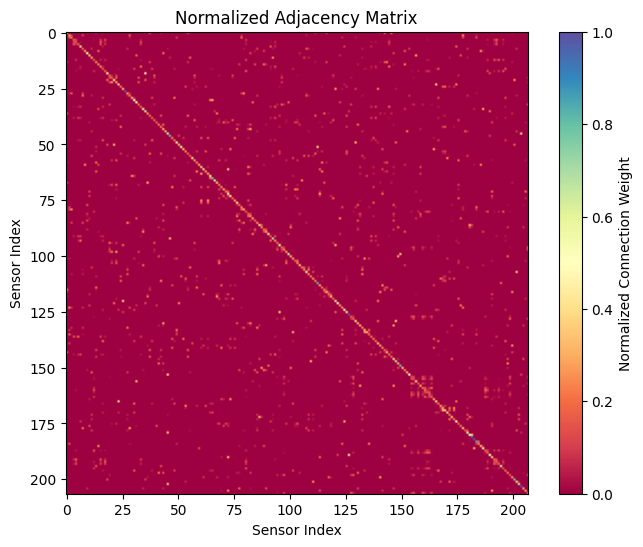

KNN Non-zero entries: 949


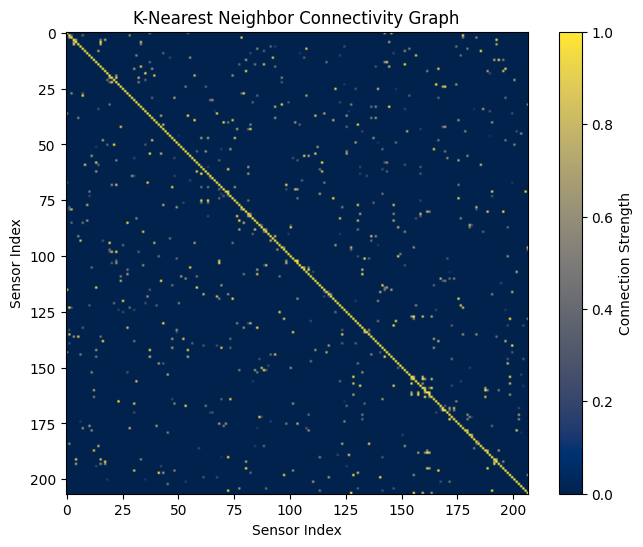

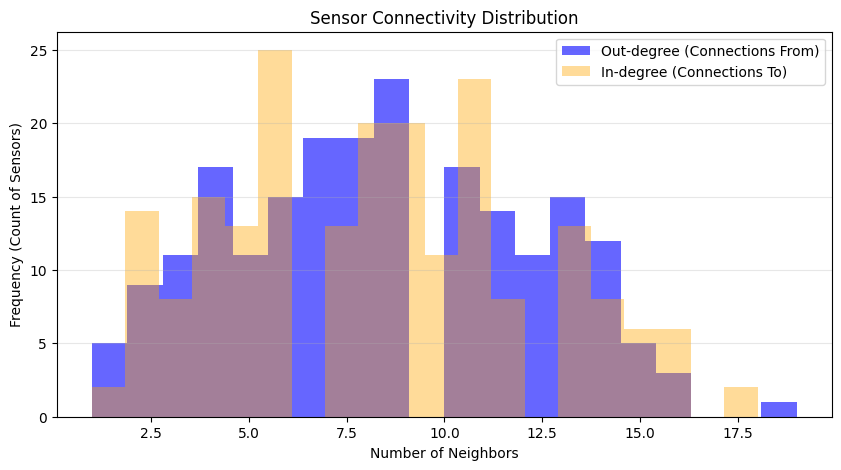

Average connections per sensor: 8.32
Max connections for one sensor: 19


In [ ]:

# Step 1b: Inspect Adjacency dataset
# ============================================================
# This step analyzes the spatial relationships between sensors.
# The adjacency matrix represents how traffic at one sensor
# is influenced by nearby sensors in the road network.

import pickle
import numpy as np
import matplotlib.pyplot as plt

# Load adjacency data
metr_path = "/content/drive/MyDrive/spatiotemporal-traffic-forecasting/datasets/raw/metr_la/"

with open(metr_path + "adj_metr_la.pkl", "rb") as f:
    adj_data = pickle.load(f, encoding="latin1")


sensor_ids = adj_data[0]          # list of sensor IDs (order matters)
sensor_id_to_ind = adj_data[1]    # mapping from sensor ID → index
adj_mx = adj_data[2]              # adjacency matrix (graph)

# Basic inspection
print("Type of adj_data:", type(adj_data))
print("Number of sensors:", len(sensor_ids))
print("Adjacency matrix shape:", adj_mx.shape)

print("\nFirst 5 sensor IDs:")
print(sensor_ids[:5])

print("\nFirst 5 mapping entries:")
print(list(sensor_id_to_ind.items())[:5])

# Visualize adjacency matrix
plt.figure(figsize=(8, 6))
plt.imshow(adj_mx, aspect="auto")
plt.title("METR-LA Adjacency Matrix (Sensor Connectivity)")
plt.xlabel("Sensor Index")
plt.ylabel("Sensor Index")
plt.colorbar(label="Connection Weight")
plt.show()

# Compute sparsity (important graph property)
nonzero = np.count_nonzero(adj_mx)
total = adj_mx.size
sparsity = 100 * (1 - nonzero / total)

print("\nNon-zero entries:", nonzero)
print("Total entries:", total)
print(f"Sparsity (% zeros): {sparsity:.2f}")

# Verify alignment with traffic dataset (critical for modeling)
if 'df' in globals():
    print("\nFirst 5 df columns:", df.columns[:5].tolist())
    print("First 5 sensor_ids:", sensor_ids[:5])
    print("Columns aligned with adjacency IDs?:",
          df.columns[:len(sensor_ids)].tolist() == sensor_ids)

# Added: Normalize adjacency matrix if required by GNN models
def normalize_adj(mx):
    "Row-normalize sparse matrix"
    rowsum = np.array(mx.sum(1))
    r_inv = np.power(rowsum, -1).flatten()
    r_inv[np.isinf(r_inv)] = 0.
    r_mat_inv = np.diag(r_inv)
    return r_mat_inv.dot(mx)

adj_mx_normalized = normalize_adj(adj_mx)

print("Check: First row sum (should be 1.0 or 0.0):", np.sum(adj_mx_normalized[0]))

#ADDED: Normalized Adjacency Graph Visualization
plt.figure(figsize=(8, 6))
plt.imshow(adj_mx_normalized, cmap="Spectral")
plt.title("Normalized Adjacency Matrix")
plt.xlabel("Sensor Index")
plt.ylabel("Sensor Index")
plt.colorbar(label="Normalized Connection Weight")
plt.show()

# TODO: Explore alternative graph constructions- distance-based
# ============================================================
# ADDED: k-nearest neighbor Graph
# ============================================================

def build_knn_from_adj(adj_mx, k=5):
    num_nodes = adj_mx.shape[0]
    knn_adj = np.zeros_like(adj_mx)

    for i in range(num_nodes):
        neighbors = np.argsort(adj_mx[i])[-k:]  # top k

        for j in neighbors:
            if adj_mx[i, j] > 0:
                knn_adj[i, j] = adj_mx[i, j]

    return knn_adj


adj_knn = build_knn_from_adj(adj_mx, k=5)

print("KNN Non-zero entries:", np.count_nonzero(adj_knn))


# Visualization
plt.figure(figsize=(8, 6))

plt.imshow(adj_knn, cmap="cividis")
plt.title("K-Nearest Neighbor Connectivity Graph")
plt.xlabel("Sensor Index")
plt.ylabel("Sensor Index")
plt.colorbar(label="Connection Strength")
plt.show()


# Added: Analyze degree distribution of nodes (number of connections per sensor)
out_degrees = np.sum(adj_mx > 0, axis=1)
in_degrees = np.sum(adj_mx > 0, axis=0)

plt.figure(figsize=(10, 5))
plt.hist(out_degrees, bins=20, alpha=0.6, label='Out-degree (Connections From)', color='blue')
plt.hist(in_degrees, bins=20, alpha=0.4, label='In-degree (Connections To)', color='orange')
plt.title("Sensor Connectivity Distribution")
plt.xlabel("Number of Neighbors")
plt.ylabel("Frequency (Count of Sensors)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Average connections per sensor: {np.mean(out_degrees):.2f}")
print(f"Max connections for one sensor: {np.max(out_degrees)}")

Total values: 7094304
Zero values: 575302
Percentage of zeros: 8.11%

Validation Check:
Minimum non-zero speed: 0.33 mph
Conclusion: Since the drops go from highway speeds directly to 0.0 (and not 1-5 mph), these are sensor errors.


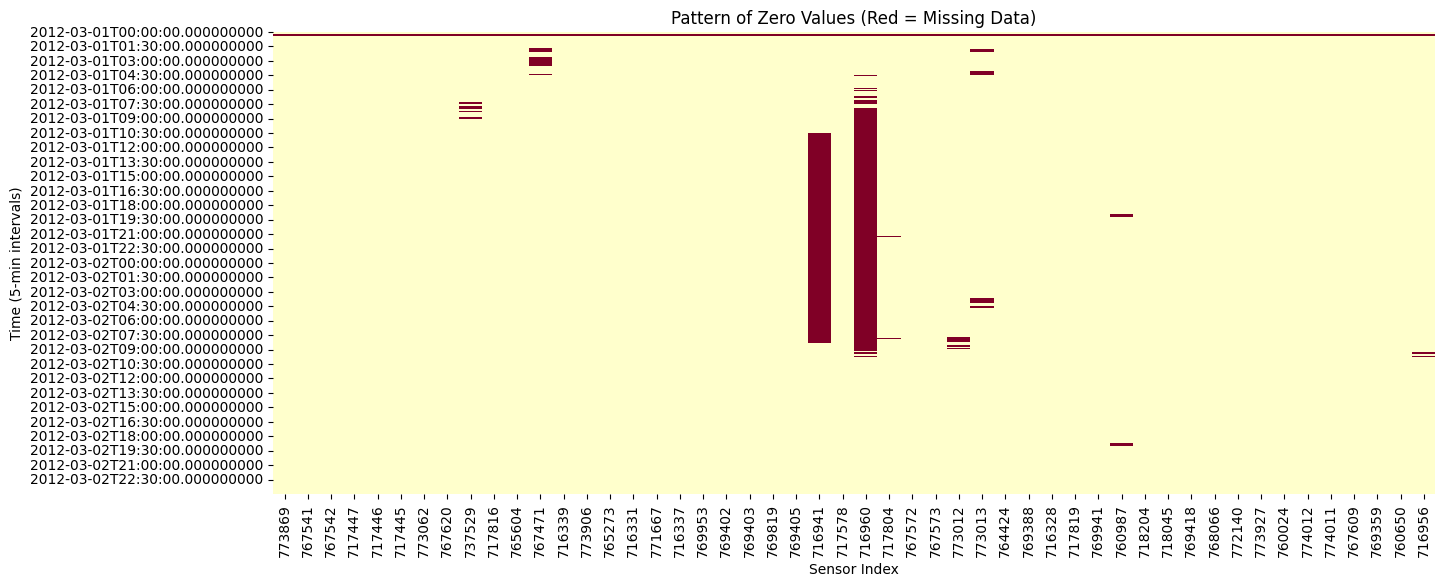

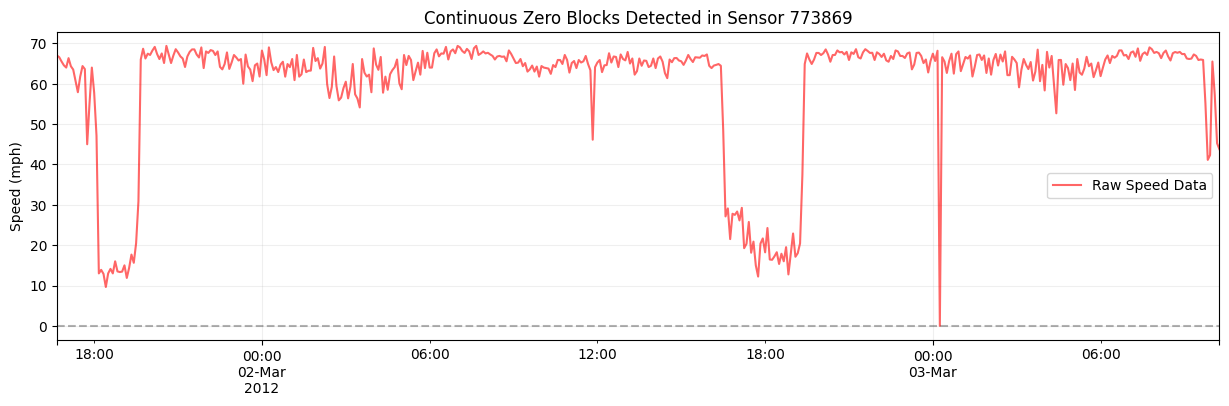

In [ ]:
# Step 2: handle zero values/ missing
# In traffic speed data, zeros may indicate missing or faulty sensor readings.
zero_count = (df == 0).sum().sum()
total_values = df.size

print("Total values:", total_values)
print("Zero values:", zero_count)
print(f"Percentage of zeros: {(zero_count / total_values) * 100:.2f}%")

# Added: Validate whether zero values represent actual traffic conditions or missing data
print("\nValidation Check:")
print(f"Minimum non-zero speed: {df[df > 0].min().min():.2f} mph")
print("Conclusion: Since the drops go from highway speeds directly to 0.0 (and not 1-5 mph), these are sensor errors.")

# Added: Compare zero patterns across different sensors
plt.figure(figsize=(15, 6))
sns.heatmap(df.iloc[:576, :50] == 0, cbar=False, cmap='YlOrRd')
plt.title("Pattern of Zero Values (Red = Missing Data)")
plt.xlabel("Sensor Index")
plt.ylabel("Time (5-min intervals)")
plt.show()

# Added: Visualize time-series segments to detect continuous zero blocks
# Identify the first sensor that actually contains zeros
sensors_with_zeros = df.columns[(df == 0).sum() > 0]
if len(sensors_with_zeros) > 0:
    target_sensor = sensors_with_zeros[0]

    plt.figure(figsize=(15, 4))
    # Plotting a 500-step window where we know zeros exist
    df[target_sensor].iloc[200:700].plot(label="Raw Speed Data", color='red', alpha=0.6)
    plt.title(f"Continuous Zero Blocks Detected in Sensor {target_sensor}")
    plt.ylabel("Speed (mph)")
    plt.axhline(0, color='black', linestyle='--', alpha=0.3)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
else:
    print("No sensors with zero values found in this subset.")

In [ ]:

#STEP 3: start with data pre-processing..
import numpy as np

# Replace zeros with NaN
df_clean = df.replace(0, np.nan)

# Interpolate
df_clean = df_clean.interpolate(method="linear", axis=0)

# Fill remaining NaNs (edges)
df_clean = df_clean.ffill().bfill()

print("Missing values after cleaning:", df_clean.isnull().sum().sum())

Missing values after cleaning: 0


In [ ]:
#a. split the dataset :
# Added: Experiment with different split ratios (e.g., 80/10/10)

num_timesteps = len(df_clean)

# train_end = int(num_timesteps * 0.70)
# val_end = int(num_timesteps * 0.85)

train_end = int(num_timesteps * 0.80)
val_end = int(num_timesteps * 0.90)

train_df = df_clean.iloc[:train_end]
val_df = df_clean.iloc[train_end:val_end]
test_df = df_clean.iloc[val_end:]

print("Total shape:", df_clean.shape)
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain range:", train_df.index.min(), "to", train_df.index.max())
print("Validation range:", val_df.index.min(), "to", val_df.index.max())
print("Test range:", test_df.index.min(), "to", test_df.index.max())

Total shape: (34272, 207)
Train shape: (27417, 207)
Validation shape: (3427, 207)
Test shape: (3428, 207)

Train range: 2012-03-01 00:00:00 to 2012-06-04 04:40:00
Validation range: 2012-06-04 04:45:00 to 2012-06-16 02:15:00
Test range: 2012-06-16 02:20:00 to 2012-06-27 23:55:00


In [ ]:
# b. Apply normalization : now do normalization for all sensors.

#TO DO: per-sensor normalization (better if time termits)

#Convert to numpy
train_data = train_df.values
val_data = val_df.values
test_data = test_df.values

# Compute mean and std ONLY from training data
# mean = train_data.mean()
# std = train_data.std()

#(Per sensor)
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)

print("Train mean:", mean)
print("Train std:", std)

train_data = (train_data - mean) / std
val_data = (val_data - mean) / std
test_data = (test_data - mean) / std

print("After normalization:")
print("Train mean (approx):", train_data.mean())
print("Train std (approx):", train_data.std())

Train mean: [62.00072279 64.49605182 64.51852041 52.91807231 50.02776094 54.78415259
 58.52687005 63.0311497  60.71790934 56.91877891 60.30229488 62.97675357
 40.93382833 64.25645042 55.64169862 50.13144188 30.83980554 56.85331915
 55.86952472 58.48648159 64.61107606 60.3634166  47.81530631 54.40707802
 63.8593749  57.43782229 52.0674064  61.58746493 65.71693648 43.44570079
 58.94575066 65.91952082 63.97013037 59.3249023  62.90921676 60.9784416
 64.89137383 62.84736632 48.75832712 57.41425509 61.43906895 57.43137873
 59.70107113 54.43388679 66.35763495 66.3026351  61.24898031 53.67498506
 50.05197417 60.20370257 59.11306567 50.99147277 57.03235086 54.21326749
 58.57191752 60.65417728 39.06775342 55.36078885 60.43115659 60.3548724
 54.54816673 54.04941737 60.52972747 57.45414758 63.00085497 62.69126312
 65.49627872 66.75514077 62.65785102 58.72914217 58.95334038 60.52746015
 57.19860081 51.92273559 62.90213811 47.01365266 50.35647209 55.81475196
 63.9766314  64.35638395 62.47289995 51.3

In [ ]:
#c. Sequence creation
import numpy as np

def create_sequences(data, input_len=12, output_len=3):
    X, Y = [], []

    for i in range(len(data) - input_len - output_len + 1):
        x = data[i : i + input_len]
        y = data[i + input_len : i + input_len + output_len]
        X.append(x)
        Y.append(y)

    return np.array(X), np.array(Y)

# Create sequences for 15 min prediction (3 steps)
X_train_15, Y_train_15 = create_sequences(train_data, input_len=12, output_len=3)
X_val_15, Y_val_15 = create_sequences(val_data, input_len=12, output_len=3)
X_test_15, Y_test_15 = create_sequences(test_data, input_len=12, output_len=3)

# Create sequences for 30 min prediction (6 steps)
X_train_30, Y_train_30 = create_sequences(train_data, input_len=12, output_len=6)
X_val_30, Y_val_30 = create_sequences(val_data, input_len=12, output_len=6)
X_test_30, Y_test_30 = create_sequences(test_data, input_len=12, output_len=6)

# Create sequences for 60 min prediction (12 steps)
X_train_60, Y_train_60 = create_sequences(train_data, input_len=12, output_len=12)
X_val_60, Y_val_60 = create_sequences(val_data, input_len=12, output_len=12)
X_test_60, Y_test_60 = create_sequences(test_data, input_len=12, output_len=12)


# Added: Experiment with longer input window (e.g., 24 timesteps)
# We test this against the 60-min horizon
X_train_long, Y_train_long = create_sequences(train_data, input_len=24, output_len=12)

# Added: Compare single-step vs multi-step prediction
X_train_single, Y_train_single = create_sequences(train_data, input_len=12, output_len=1)


# print("15-min horizon:")
# print("X_train_15:", X_train_15.shape)
# print("Y_train_15:", Y_train_15.shape)

# print("\n30-min horizon:")
# print("X_train_30:", X_train_30.shape)
# print("Y_train_30:", Y_train_30.shape)

# print("\n60-min horizon:")
# print("X_train_60:", X_train_60.shape)
# print("Y_train_60:", Y_train_60.shape)

# --- Verification Prints ---
print("15-min horizon (Standard):")
print(f"X: {X_train_15.shape}, Y: {Y_train_15.shape}")

print("\n60-min horizon (Standard):")
print(f"X: {X_train_60.shape}, Y: {Y_train_60.shape}")

print("\nLonger Input (24 steps) Experiment:")
print(f"X: {X_train_long.shape}, Y: {Y_train_long.shape}")

print("\nSingle-step (1 step) Experiment:")
print(f"X: {X_train_single.shape}, Y: {Y_train_single.shape}")


15-min horizon (Standard):
X: (27403, 12, 207), Y: (27403, 3, 207)

60-min horizon (Standard):
X: (27394, 12, 207), Y: (27394, 12, 207)

Longer Input (24 steps) Experiment:
X: (27382, 24, 207), Y: (27382, 12, 207)

Single-step (1 step) Experiment:
X: (27405, 12, 207), Y: (27405, 1, 207)


In [ ]:
#save the dataset
import numpy as np

save_path = "/content/drive/MyDrive/spatiotemporal-traffic-forecasting/basic_preprocessed/"

# Create folder if not exists
import os
os.makedirs(save_path, exist_ok=True)

# Save 15-min horizon (start with this)
np.save(save_path + "X_train_15.npy", X_train_15)
np.save(save_path + "Y_train_15.npy", Y_train_15)

np.save(save_path + "X_val_15.npy", X_val_15)
np.save(save_path + "Y_val_15.npy", Y_val_15)

np.save(save_path + "X_test_15.npy", X_test_15)
np.save(save_path + "Y_test_15.npy", Y_test_15)

print("Saved successfully!")

Saved successfully!
